# Tilt angle calibration following Bramati et al. (2024)

Horizontal flights for calibration @scirocco:/indian/UAS_project_data/2025_11_03_Arluno/MAVIC/FlightRecords:
* DJIFlightRecord_2025-11-03_[10-45-24].txt
* DJIFlightRecord_2025-11-03_[11-08-09].txt
* DJIFlightRecord_2025-11-03_[10-56-31].txt

In [27]:
import os
import sys
sys.path.append('./..')
from src.preprocess import PreprocessFlightRecord,PlotFlightRecord
from src.tilt_angle import AddTiltAngle,AddGroundSpeed
import glob
import pandas as pd
import numpy as np

%reload_ext autoreload
%autoreload 2


flights_dict = {
    'DJIFlightRecord_2025-11-03_[10-45-24].csv' : {
        'itime_int' : [500,4450], # Interval of indices to consider 
    },
    'DJIFlightRecord_2025-11-03_[10-56-31].csv' : {
        'itime_int' : [200,5200], # Interval of indices to consider 
    },
    'DJIFlightRecord_2025-11-03_[11-08-09].csv' : {
        'itime_int' : [200,4700], # Interval of indices to consider 
    },
    }

files = np.array(sorted(glob.glob(f"/indian/UAS_project_data/2025_11_03_Arluno/MAVIC/FlightRecords/*")))
files = files[[ True if os.path.basename(file) in flights_dict.keys() else False for file in files ]]

fr_df_ar = []
for file in files:
    flight_dict = flights_dict[os.path.basename(file)]
    fr_df = PreprocessFlightRecord(file,itime_int=flight_dict['itime_int'])
    fr_df = AddTiltAngle(fr_df)
    fr_df = AddGroundSpeed(fr_df)
    fr_df_ar.append(fr_df)

fr_df = pd.concat(fr_df_ar)

fr_df.sort_values(by='CUSTOM.dateTime_dt',inplace=True)


Dropping 0 rows with datetime errors.
Dropping 0 rows with datetime errors.
Dropping 0 rows with datetime errors.


Dropping 0 rows with datetime errors.
Dropping 0 rows with datetime errors.
Dropping 0 rows with datetime errors.


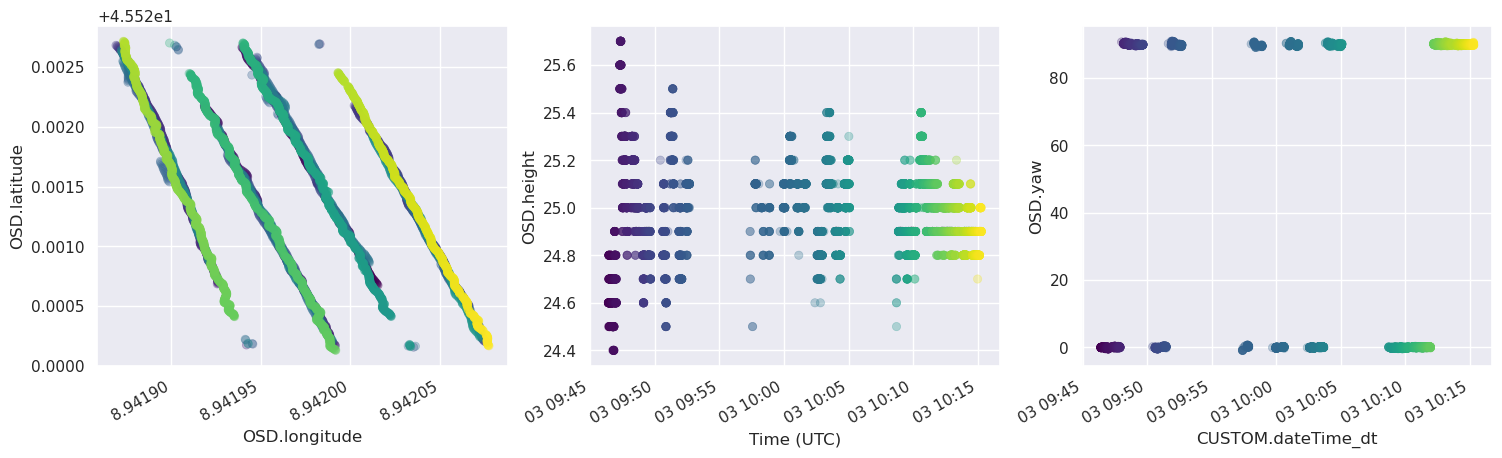

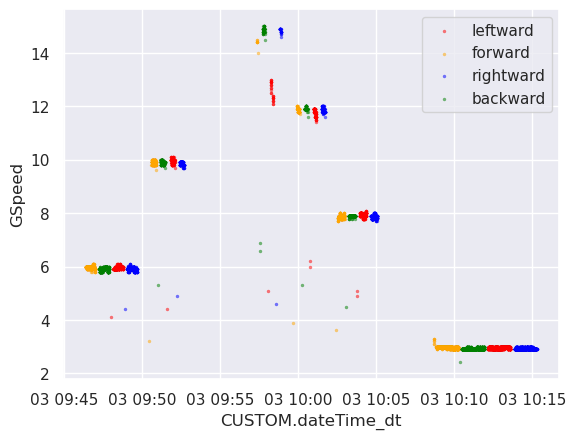

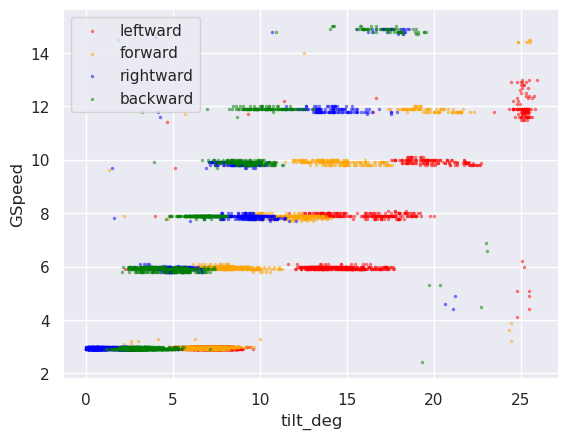

In [48]:
import os
import sys
sys.path.append('./..')
from src.preprocess import PreprocessFlightRecord,PlotFlightRecord
from src.tilt_angle import AddTiltAngle,AddGroundSpeed
import glob
import pandas as pd
import numpy as np

%reload_ext autoreload
%autoreload 2


flights_dict = {
    'DJIFlightRecord_2025-11-03_[10-45-24].csv' : {
        'itime_int' : [500,4450], # Interval of indices to consider 
    },
    'DJIFlightRecord_2025-11-03_[10-56-31].csv' : {
        'itime_int' : [200,5200], # Interval of indices to consider 
    },
    'DJIFlightRecord_2025-11-03_[11-08-09].csv' : {
        'itime_int' : [200,4700], # Interval of indices to consider 
    },
    }

files = np.array(sorted(glob.glob(f"/indian/UAS_project_data/2025_11_03_Arluno/MAVIC/FlightRecords/*")))
files = files[[ True if os.path.basename(file) in flights_dict.keys() else False for file in files ]]

fr_df_ar = []
for file in files:
    flight_dict = flights_dict[os.path.basename(file)]
    fr_df = PreprocessFlightRecord(file,itime_int=flight_dict['itime_int'])
    fr_df = AddTiltAngle(fr_df)
    fr_df = AddGroundSpeed(fr_df)
    fr_df_ar.append(fr_df)

fr_df = pd.concat(fr_df_ar)

fr_df.sort_values(by='CUSTOM.dateTime_dt',inplace=True)

# fr_df = fr_df.loc[
#     (fr_df['OSD.height']<26) & 
#     (fr_df['OSD.height']>24) & 
#     (fr_df['OSD.longitude']<8.9421)
#    ]

fr_df = fr_df.loc[((fr_df['OSD.yaw'] > 89) & (fr_df['OSD.yaw'] < 91)) | ((fr_df['OSD.yaw'] > -1) & (fr_df['OSD.yaw'] < 1)) ]
fr_df.reset_index(inplace=True,drop=True)

window=100
fr_df['GSpeed_mean'] = fr_df['GSpeed'].rolling(window=window).mean()
fr_df['GSpeed_rel_a'] = np.abs(fr_df['GSpeed_mean']-fr_df['GSpeed'])/fr_df['GSpeed_mean'] 
fr_df = fr_df.loc[(fr_df['GSpeed_rel_a']< 0.03)].reset_index(drop=True)
PlotFlightRecord(fr_df)
plt.show()

import seaborn as sns

sns.scatterplot(
    data=fr_df.loc[(fr_df['OSD.xSpeed']>0) & (fr_df['OSD.yaw'] > 89) & (fr_df['OSD.yaw'] < 91)],
    x='CUSTOM.dateTime_dt',
    y='GSpeed',
    color='red',
    edgecolor=None,
    s=5,
    alpha=0.5,
    label='leftward',
)
sns.scatterplot(
    data=fr_df.loc[(fr_df['OSD.xSpeed']>0) & (fr_df['OSD.yaw'] > -1) & (fr_df['OSD.yaw'] < 1)],
    x='CUSTOM.dateTime_dt',
    y='GSpeed',
    color='orange',
    edgecolor=None,
    s=5,
    alpha=0.5,    
    label='forward',
)
sns.scatterplot(
    data=fr_df.loc[(fr_df['OSD.xSpeed']<0) & (fr_df['OSD.yaw'] > 89) & (fr_df['OSD.yaw'] < 91)],
    x='CUSTOM.dateTime_dt',
    y='GSpeed',
    color='blue',
    edgecolor=None,
    s=5,
    alpha=0.5,
    label='rightward',
)
sns.scatterplot(
    data=fr_df.loc[(fr_df['OSD.xSpeed']<0) & (fr_df['OSD.yaw'] > -1) & (fr_df['OSD.yaw'] < 1)],
    x='CUSTOM.dateTime_dt',
    y='GSpeed',
    color='green',
    edgecolor=None,
    s=5,
    alpha=0.5,    
    label='backward',
)
plt.show()

sns.scatterplot(
    data=fr_df.loc[(fr_df['OSD.xSpeed']>0) & (fr_df['OSD.yaw'] > 89) & (fr_df['OSD.yaw'] < 91)],
    x='tilt_deg',
    y='GSpeed',
    color='red',
    edgecolor=None,
    s=5,
    alpha=0.5,
    label='leftward',
)
sns.scatterplot(
    data=fr_df.loc[(fr_df['OSD.xSpeed']>0) & (fr_df['OSD.yaw'] > -1) & (fr_df['OSD.yaw'] < 1)],
    x='tilt_deg',
    y='GSpeed',
    color='orange',
    edgecolor=None,
    s=5,
    alpha=0.5,    
    label='forward',
)
sns.scatterplot(
    data=fr_df.loc[(fr_df['OSD.xSpeed']<0) & (fr_df['OSD.yaw'] > 89) & (fr_df['OSD.yaw'] < 91)],
    x='tilt_deg',
    y='GSpeed',
    color='blue',
    edgecolor=None,
    s=5,
    alpha=0.5,
    label='rightward',
)
sns.scatterplot(
    data=fr_df.loc[(fr_df['OSD.xSpeed']<0) & (fr_df['OSD.yaw'] > -1) & (fr_df['OSD.yaw'] < 1)],
    x='tilt_deg',
    y='GSpeed',
    color='green',
    edgecolor=None,
    s=5,
    alpha=0.5,    
    label='backward',
)

plt.show()

## Direct method

-182.97703275204282 98.75441271622827 11.036010433453944 2.657464205968275


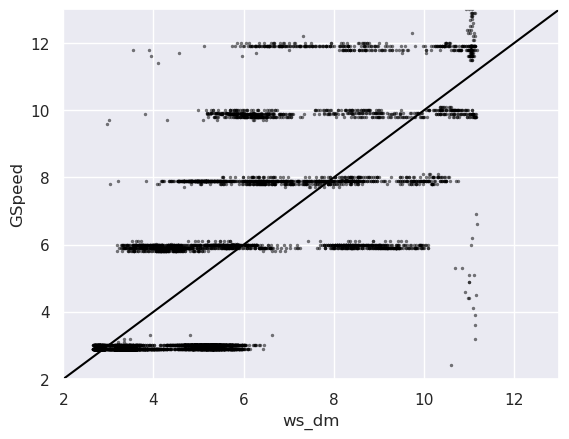

In [51]:
import numpy as np
c3,c2,c1,c0 = np.polyfit(x=fr_df['tilt_rad'],y=fr_df['GSpeed'],deg=3)

# Compute wind speed from Direct Model (polyfit)
fr_df['ws_dm'] = c3 * fr_df['tilt_rad']**3 + c2* fr_df['tilt_rad']**2 + c1 * fr_df['tilt_rad'] + c0

import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(
    data=fr_df,
    x='ws_dm',
    y='GSpeed',
    color='black',
    edgecolor=None,
    s=5,
    alpha=0.5,    
)

plt.plot(np.arange(0,17,1),color='black')

plt.xlim((2,13))
plt.ylim((2,13))
print(c3,c2,c1,c0)

# Separate forward and backward, leftward, rightward

Dropping 0 rows with datetime errors.
Dropping 0 rows with datetime errors.
Dropping 0 rows with datetime errors.


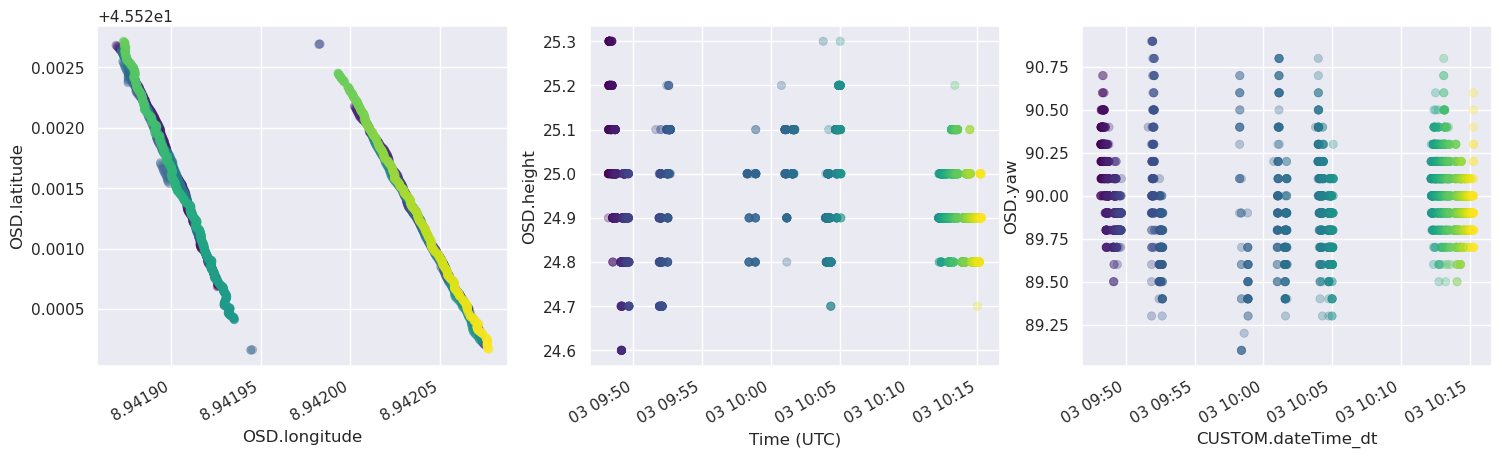

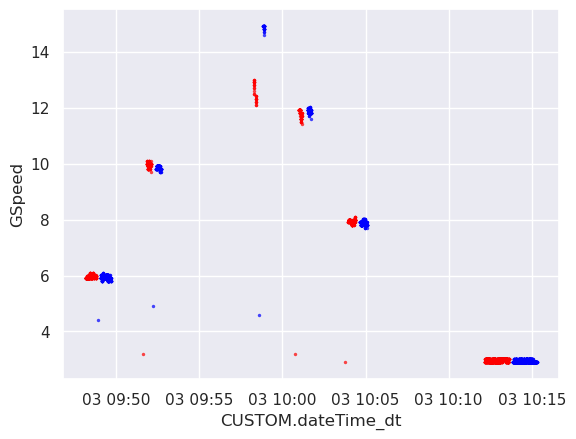

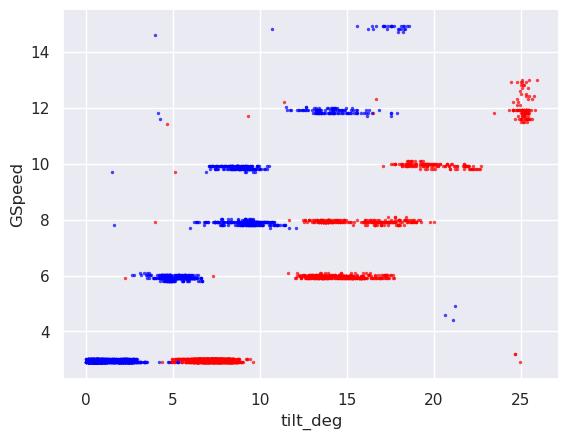

In [37]:
import os
import sys
sys.path.append('./..')
from src.preprocess import PreprocessFlightRecord,PlotFlightRecord
from src.tilt_angle import AddTiltAngle,AddGroundSpeed
import glob
import pandas as pd
import numpy as np

%reload_ext autoreload
%autoreload 2


flights_dict = {
    'DJIFlightRecord_2025-11-03_[10-45-24].csv' : {
        'itime_int' : [500,4450], # Interval of indices to consider 
    },
    'DJIFlightRecord_2025-11-03_[10-56-31].csv' : {
        'itime_int' : [200,5200], # Interval of indices to consider 
    },
    'DJIFlightRecord_2025-11-03_[11-08-09].csv' : {
        'itime_int' : [200,4700], # Interval of indices to consider 
    },
}

files = np.array(sorted(glob.glob(f"/indian/UAS_project_data/2025_11_03_Arluno/MAVIC/FlightRecords/*")))
files = files[[ True if os.path.basename(file) in flights_dict.keys() else False for file in files ]]

fr_df_ar = []
for file in files:
    flight_dict = flights_dict[os.path.basename(file)]
    fr_df = PreprocessFlightRecord(file,itime_int=flight_dict['itime_int'])
    fr_df = AddTiltAngle(fr_df)
    fr_df = AddGroundSpeed(fr_df)
    fr_df_ar.append(fr_df)

fr_df = pd.concat(fr_df_ar)

fr_df.sort_values(by='CUSTOM.dateTime_dt',inplace=True)

# fr_df = fr_df.loc[
#     (fr_df['OSD.height']<26) & 
#     (fr_df['OSD.height']>24) & 
#     (fr_df['OSD.longitude']<8.9421)
#    ]

fr_df = fr_df.loc[((fr_df['OSD.yaw'] > 89) & (fr_df['OSD.yaw'] < 91)) ]# | ((fr_df['OSD.yaw'] > -1) & (fr_df['OSD.yaw'] < 1)) ]
fr_df.reset_index(inplace=True,drop=True)

window=100
fr_df['GSpeed_mean'] = fr_df['GSpeed'].rolling(window=window).mean()
fr_df['GSpeed_rel_a'] = np.abs(fr_df['GSpeed_mean']-fr_df['GSpeed'])/fr_df['GSpeed_mean'] 
fr_df = fr_df.loc[(fr_df['GSpeed_rel_a']< 0.03)].reset_index(drop=True)
PlotFlightRecord(fr_df)

plt.show()

import seaborn as sns

sns.scatterplot(
    data=fr_df.loc[fr_df['OSD.xSpeed']>0],
    x='CUSTOM.dateTime_dt',
    y='GSpeed',
    color='red',
    edgecolor=None,
    s=5,
    alpha=0.7,
)
sns.scatterplot(
    data=fr_df.loc[fr_df['OSD.xSpeed']<0],
    x='CUSTOM.dateTime_dt',
    y='GSpeed',
    color='blue',
    edgecolor=None,
    s=5,
    alpha=0.7,
)

plt.show()

sns.scatterplot(
    data=fr_df.loc[fr_df['OSD.xSpeed']>0],
    x='tilt_deg',
    y='GSpeed',
    color='red',
    edgecolor=None,
    s=5,
    alpha=0.7,
)
sns.scatterplot(
    data=fr_df.loc[fr_df['OSD.xSpeed']<0],
    x='tilt_deg',
    y='GSpeed',
    color='blue',
    edgecolor=None,
    s=5,
    alpha=0.7,
)

plt.show()

-49.17617413932765 32.999839129565565 15.019800787351217 2.698827322061377


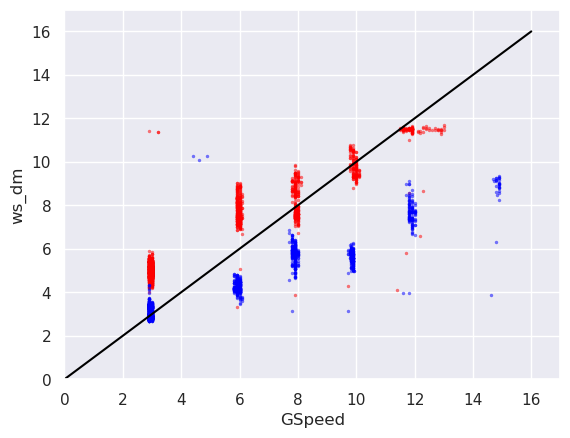

In [36]:
import numpy as np
c3,c2,c1,c0 = np.polyfit(x=fr_df['tilt_rad'],y=fr_df['GSpeed'],deg=3)

# Compute wind speed from Direct Model (polyfit)
fr_df['ws_dm'] = c3 * fr_df['tilt_rad']**3 + c2* fr_df['tilt_rad']**2 + c1 * fr_df['tilt_rad'] + c0

import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(
    data=fr_df.loc[fr_df['OSD.xSpeed']>0],
    x='GSpeed',
    y='ws_dm',
    color='red',
    edgecolor=None,
    s=5,
    alpha=0.5,
)
sns.scatterplot(
    data=fr_df.loc[fr_df['OSD.xSpeed']<0],
    x='GSpeed',
    y='ws_dm',
    color='blue',
    edgecolor=None,
    s=5,
    alpha=0.5,
)

plt.plot(np.arange(0,17,1),color='black')

plt.xlim((0,17))
plt.ylim((0,17))
print(c3,c2,c1,c0)

## Trisonica for ref wind speed

In [33]:
tris_df = pd.read_csv('/indian/UAS_project_data/2025_11_03_Arluno/trisonica/20251103_092855.csv',sep=';',header=8)
vars_to_keep = ['C.wspd','C.wdir']
tris_df = tris_df[vars_to_keep]

KeyError: "None of [Index(['C.wspd', 'C.wdir'], dtype='object')] are in the [columns]"

In [ ]:
tris_df

,Time (UTC),SKH1_70727633.pr,SKH1_70727633.bat,SKH1_70727633.temp,SKH1_70727633.rh,SKH1_70727633.lat,SKH1_70727633.lon,SKH1_70727633.alt,C.wspd,C.wdir,C.windU,C.windV,C.windW,C.temp,C.rh,C.pr,C.pitch,C.roll,C.heading
0,09:28:55.343,99975,8.26,19.0,42.4,45.520431,8.94276,197.1,0.84,261,0.78,0.13,-0.28,16.27,64.9,100172,3.8,0.5,0
1,09:28:55.472,,,,,,,,0.98,256,0.92,0.22,-0.23,16.15,65.3,100172,2.5,-1.2,0
2,09:28:55.661,,,,,,,,1.17,256,1.13,0.27,-0.13,15.95,66.1,100173,3.8,-0.2,0
3,09:28:55.861,99972,8.229,19.06,42.44,,,,1.16,262,1.15,0.15,-0.07,15.87,66.4,100174,4.2,-0.2,0
4,09:28:56.062,,,,,,,,0.93,272,0.93,-0.03,0.09,16.05,65.8,100173,3.6,-0.3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6474,09:50:30.062,,,,,,,,1.34,278,1.33,-0.18,-0.09,15.77,81.9,100187,3.3,-0.2,0
6475,09:50:30.260,,,,,,,,1.36,278,1.35,-0.20,-0.04,15.83,81.7,100186,3.3,-0.1,0
6476,09:50:30.461,,,,,,,,1.29,287,1.23,-0.37,-0.08,15.81,81.6,100187,3.3,-0.2,0
6477,09:50:30.665,,,,,,,,1.26,292,1.16,-0.47,-0.14,15.81,81.5,100188,3.3,-0.1,0
